In [1]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import warnings 
warnings.filterwarnings("ignore")

In [2]:
df= pd.read_excel(r"C:\Users\Ganesh Bommaka\1\marketing_campaign.xlsx")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.dtypes

ID                              int64
Year_Birth                      int64
Education                      object
Marital_Status                 object
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[ns]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntMeatProducts                 int64
MntFishProducts                 int64
MntSweetProducts                int64
MntGoldProds                    int64
NumDealsPurchases               int64
NumWebPurchases                 int64
NumCatalogPurchases             int64
NumStorePurchases               int64
NumWebVisitsMonth               int64
AcceptedCmp3                    int64
AcceptedCmp4                    int64
AcceptedCmp5                    int64
AcceptedCmp1                    int64
AcceptedCmp2                    int64
Complain                        int64
Z_CostContac

In [5]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

In [6]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [7]:
df.describe(include="object")

,Education,Marital_Status
count,2240,2240
unique,5,8
top,Graduation,Married
freq,1127,864


In [8]:
df.shape

(2240, 29)

In [9]:
df["Education"].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [10]:
df["Marital_Status"].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [11]:
df[df.duplicated()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response


In [12]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [13]:
cols_to_drop = ['Z_CostContact', 'Z_Revenue']
df.drop(columns=cols_to_drop, inplace=True) # having same values

In [14]:
df.shape

(2240, 27)

<Axes: xlabel='Income'>

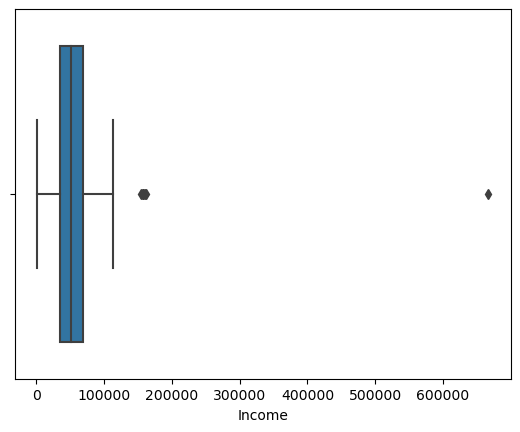

In [15]:
sn.boxplot(x="Income",data=df)

In [16]:
df.groupby("Education")["Income"].mean().round(2)

Education
2n Cycle      47633.19
Basic         20306.26
Graduation    52720.37
Master        52917.53
PhD           56145.31
Name: Income, dtype: float64

In [17]:
c=df.groupby("Education")["Income"].mean().round(2)

<BarContainer object of 5 artists>

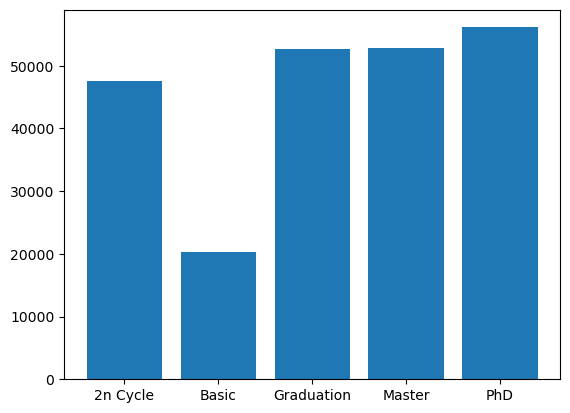

In [18]:
plt.bar(c.index,c.values)

In [19]:
df['Income'] = df['Income'].fillna(
    df.groupby('Education')['Income'].transform('median')
)
 # using seperate median for each group as income depends on education

In [20]:
df["Income"].isna().sum()

0

In [21]:
df["Income"].head()

0    58138.0
1    46344.0
2    71613.0
3    26646.0
4    58293.0
Name: Income, dtype: float64

<Axes: >

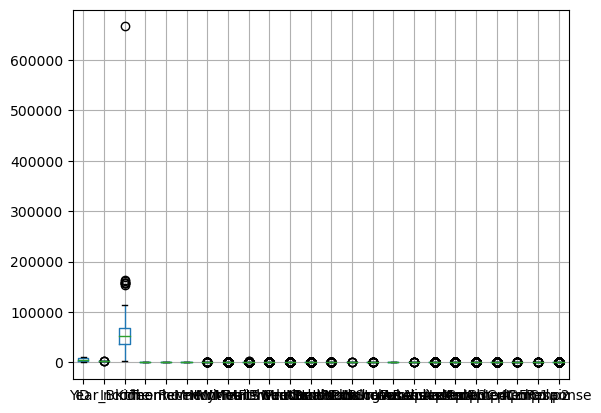

In [22]:
df.boxplot()

In [23]:
check_cols = ['Year_Birth', 'Income', 'MntWines', 'MntMeatProducts', 'NumWebVisitsMonth']
# imp columns to check outliers properly

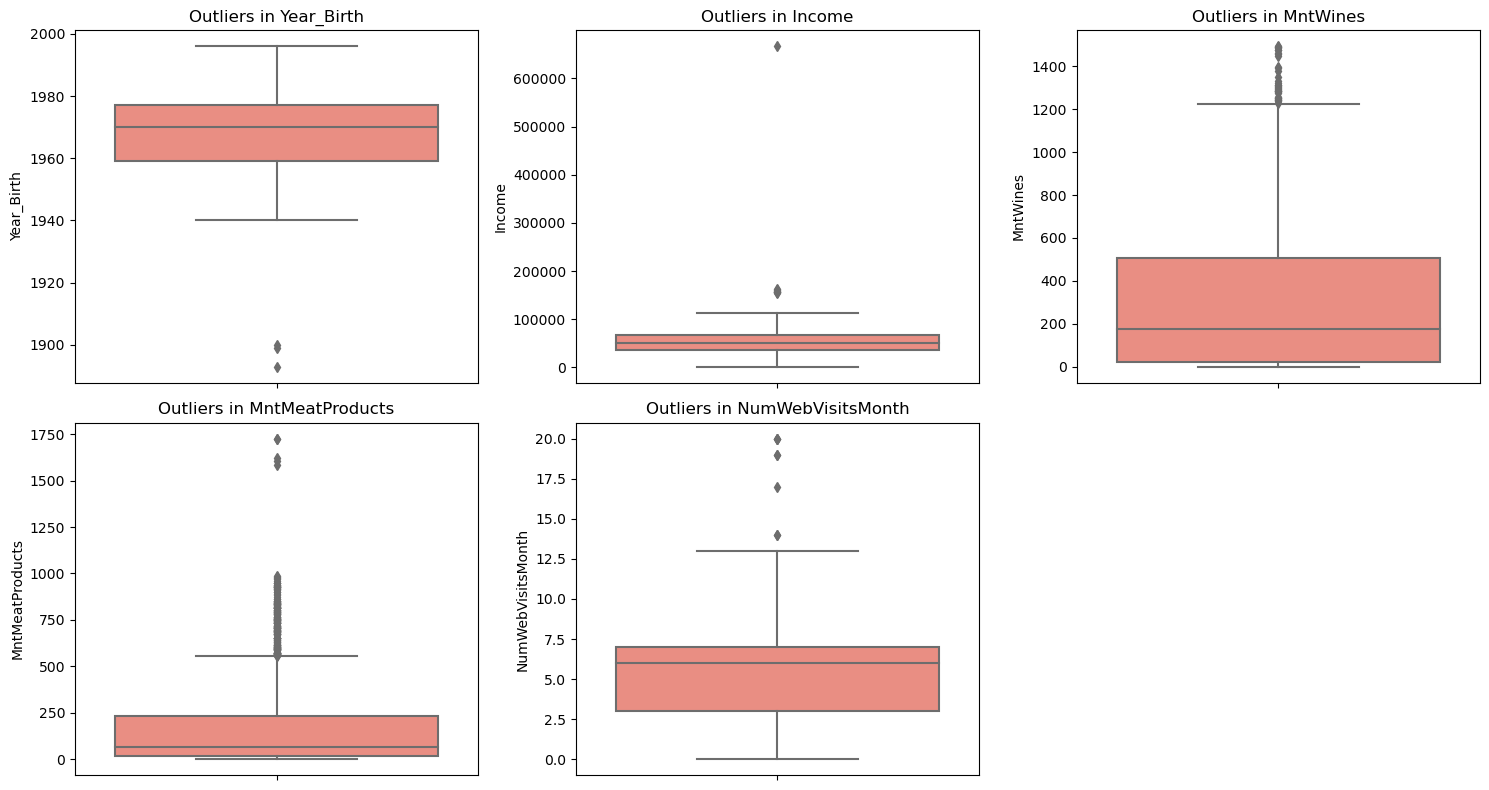

In [24]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(check_cols):
    plt.subplot(2, 3, i+1)
    sn.boxplot(y=df[col], color='salmon')
    plt.title(f'Outliers in {col}')
plt.tight_layout()
plt.show()

In [25]:
df = df[df['Year_Birth'] > 1900]   # removing logically impossible age 

In [26]:
def cap_column(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR
    df[column] = np.where(df[column] > upper_limit, upper_limit,
                          np.where(df[column] < lower_limit, lower_limit, df[column]))
    return df

In [27]:
target_cols = ['Income', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 
    'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 
    'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

# should we cap NumWebPurchases, NumCatalogPurchases, and NumDealsPurchases is that they are Count Data?

In [28]:
## Do NOT treat these: Categorical columns: Education, Marital_Status.
##Count columns: AcceptedCmp1, Response, Complain. These are usually 0 or 1.
## small-range columns: Kidhome, Teenhome

In [29]:
for col in target_cols:
    df = cap_column(df, col)

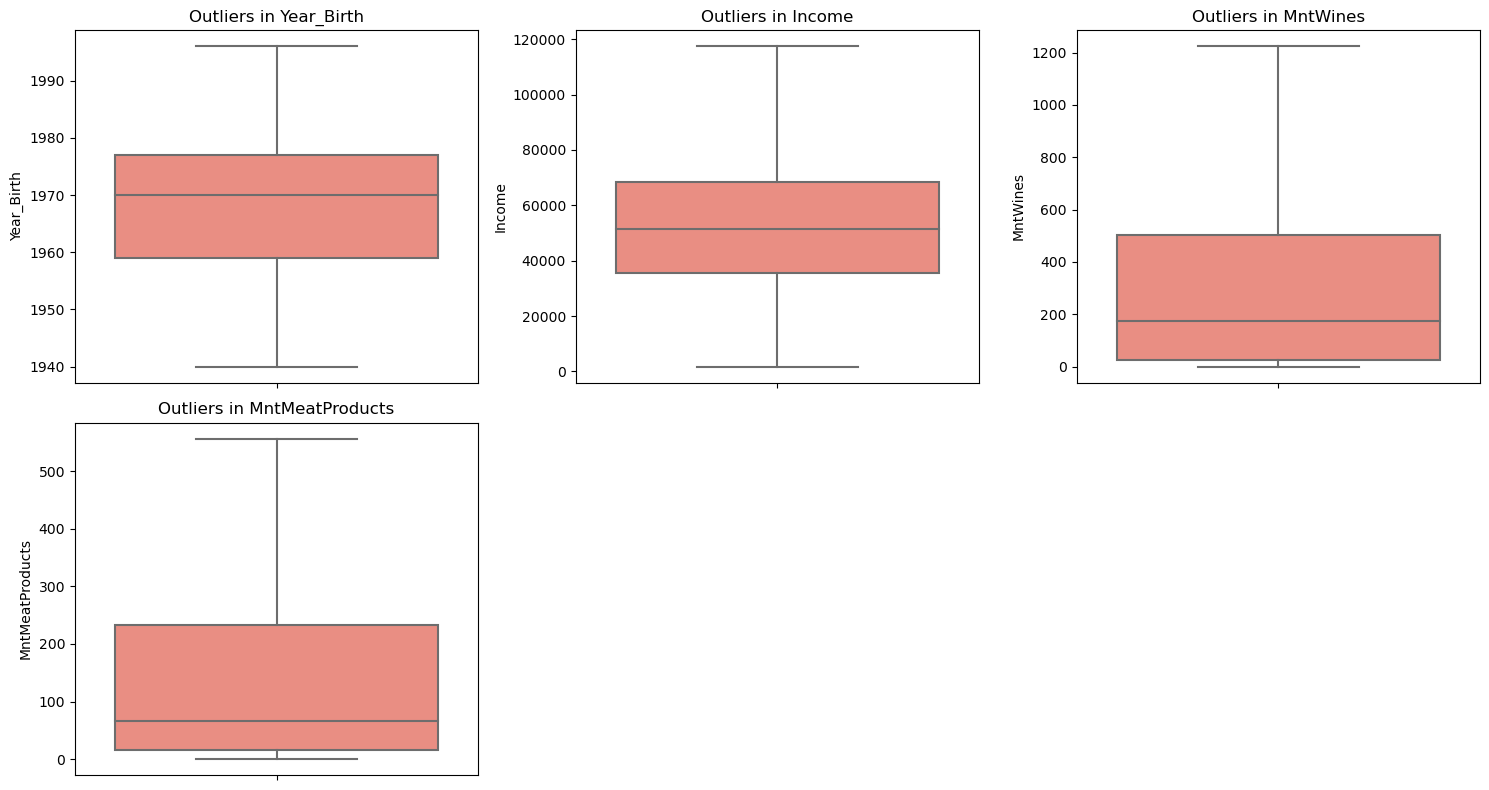

In [30]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(check_cols[:4]):
    plt.subplot(2, 3, i+1)
    sn.boxplot(y=df[col], color='salmon')
    plt.title(f'Outliers in {col}')
plt.tight_layout()
plt.show()

In [31]:
## FEATURE ENGG

In [32]:
df['Age'] = 2024 - df['Year_Birth']

In [33]:
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spent'] = df[mnt_cols].sum(axis=1)

In [34]:
purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)

In [35]:
df['Children'] = df['Kidhome'] + df['Teenhome']

In [36]:
df['Is_Parent'] = np.where(df['Children'] > 0, 1, 0)   # check if parent or not

In [37]:
df['Living_With'] = df['Marital_Status'].replace({'Married':'Partner', 'Together':'Partner', 
                                                  'Absurd':'Alone', 'Widow':'Alone', 
                                                  'YOLO':'Alone', 'Divorced':'Alone', 'Single':'Alone'})

In [38]:
df['Tenure_Days'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days

In [39]:
#Tenure_Days = how long in days each customer has been with the company compared to the newest customer

In [40]:
df_final = df.drop(columns=['ID', 'Year_Birth',  'Marital_Status'])

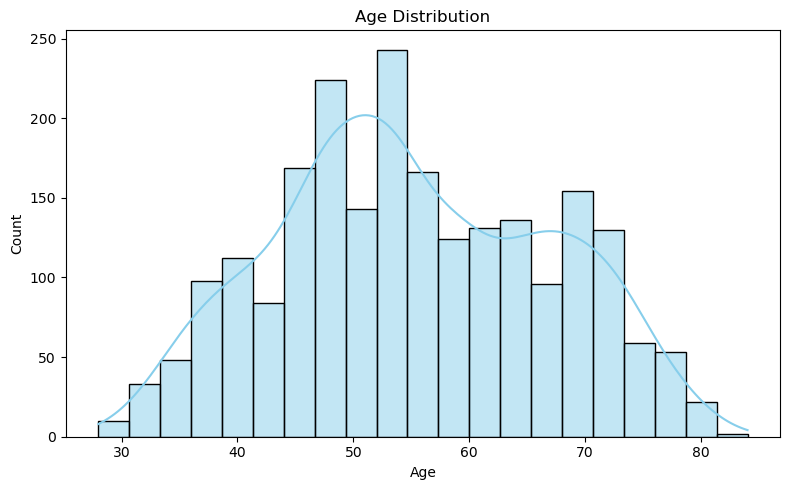

In [41]:
# Age Distribution
plt.figure(figsize=(8, 5))
sn.histplot(df_final['Age'], kde=True, color='skyblue')
plt.title('Age Distribution')
plt.tight_layout()
plt.show()


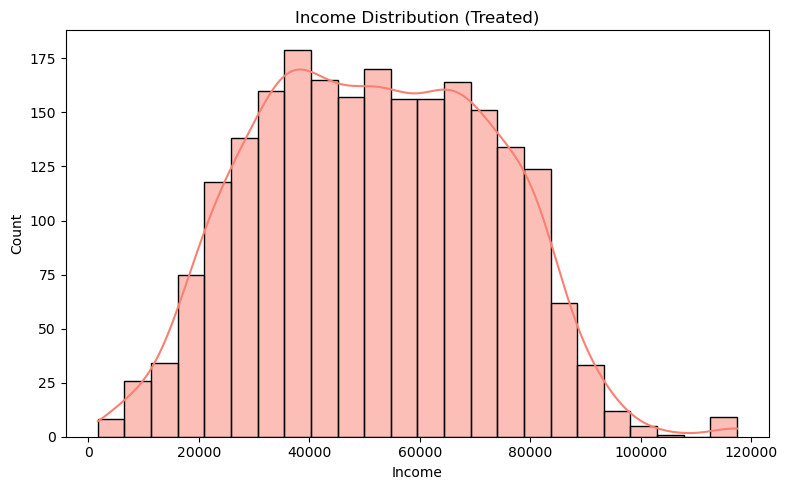

In [42]:
# Income Distribution
plt.figure(figsize=(8, 5))
sn.histplot(df_final['Income'], kde=True, color='salmon')
plt.title('Income Distribution (Treated)')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Income vs Spending (Capped)')

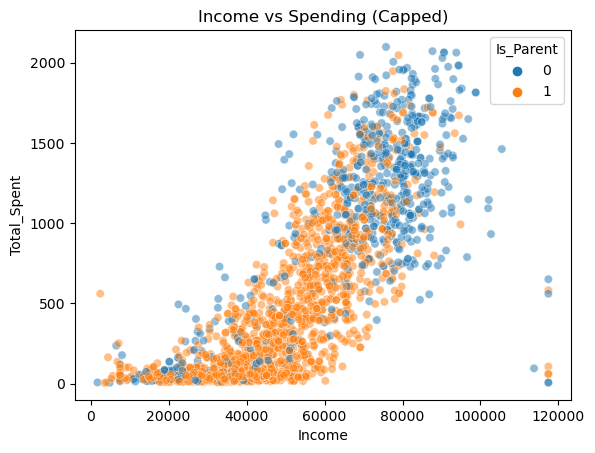

In [43]:

sn.scatterplot(x='Income', y='Total_Spent', data=df_final, hue='Is_Parent', alpha=0.5)
plt.title('Income vs Spending (Capped)')

Text(0.5, 1.0, 'Average Spending by Education')

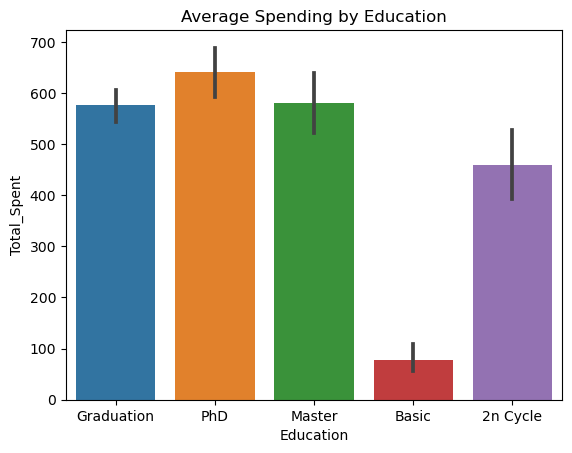

In [44]:
sn.barplot(x='Education', y='Total_Spent', data=df_final)
plt.title('Average Spending by Education')

In [45]:
df.shape

(2237, 34)

Text(0.5, 1.0, 'Average Spending by Product Category')

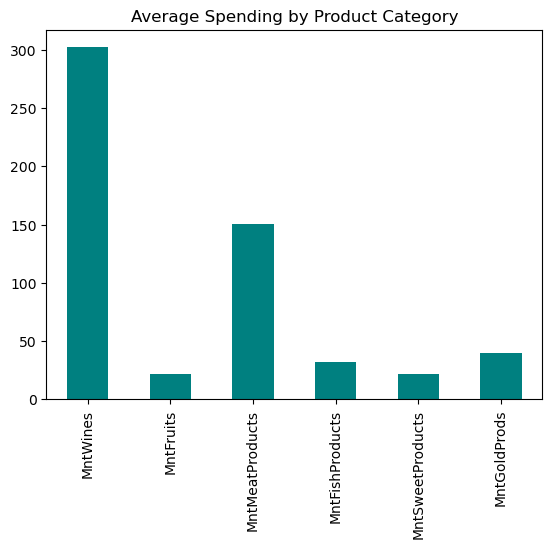

In [46]:
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_final[spend_cols].mean().plot(kind='bar', color='teal')
plt.title('Average Spending by Product Category')

In [47]:
#Mnt...	Amount	Currency ($)	To find Big Spenders (Value-based segments)
#Num...	Count	Quantity (#)	To find Frequent Shoppers (Behavior-based segments)

--------------------------------------------------------------------------------------------------------------------------------------------------------

### Step 1: Feature Selection & Encoding
Clustering algorithms calculate distance between points. Irrelevant columns like ID add noise, while text-based categories like Education cannot be processed by the math behind K-Means. Feature selection focuses the model on the variables that truly drive customer behavior (Income, Spending habits, and Demographics).

In [48]:
# 1. Drop Irrelevant Identifiers
# ID and Dt_Customer are not useful for mathematical clustering
cols_to_drop = ['ID', 'Dt_Customer', 'Year_Birth', 'Marital_Status']
df_model = df.drop(columns=cols_to_drop)

In [49]:
# Education is categorical; we convert it to numeric labels
from sklearn.preprocessing import StandardScaler, LabelEncoder
le = LabelEncoder()
df_model['Education'] = le.fit_transform(df_model['Education'])

In [50]:
# We focus on a mix of Demographics, Spending, and Engagement
selected_features = ['Income', 'Age', 'Total_Spent', 'Children', 'Tenure_Days', 'NumWebVisitsMonth', 'Education']
X = df_model[selected_features]

In [51]:
X.head()

,Income,Age,Total_Spent,Children,Tenure_Days,NumWebVisitsMonth,Education
0,58138.0,67,1551.5,0,663,7.0,2
1,46344.0,70,27.0,2,113,5.0,2
2,71613.0,59,776.0,0,312,4.0,2
3,26646.0,40,53.0,1,139,6.0,2
4,58293.0,43,422.0,1,161,5.0,4


## Step 2: Feature Scaling
Scaling gives all features a Mean of 0 and a Variance of 1, ensuring a "fair" comparison.

In [52]:
scaler = StandardScaler()

In [53]:
X_scaled = scaler.fit_transform(X)   # Transforming the data


In [54]:
print("Mean of scaled data :", np.round(X_scaled.mean(), 2))
print("Std Deviation :", X_scaled.std())

Mean of scaled data : -0.0
Std Deviation : 1.0


### Step 3: Choosing the Clustering Algorithm

--The labels here are not predefined so we use unsupervised learning
-K-Means is the industry standard for segmentation because it is computationally     efficient and produces easy-to-interpret spherical clusters.



In [55]:
wcss = []
sil_scores = []
K_range = range(2, 10)

-- WCSS (Within-Cluster Sum of Squares)
- WCSS measures how compact the clusters are.
- It is the sum of squared distances between each data point and its cluster centroid.
- High Wcss = Clusters are apread out
- Low wcss = Clusters are compact

-- Silhouette Score
- Silhouette Score measures how well-separated and well-formed the clusters are.
- +1 =	Excellent clustering
- ~0.5 = Good clustering
- 0 = Overlapping clusters
- Negative = Wrong cluster assignment

In [56]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
import numpy as np
import matplotlib as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

In [57]:
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

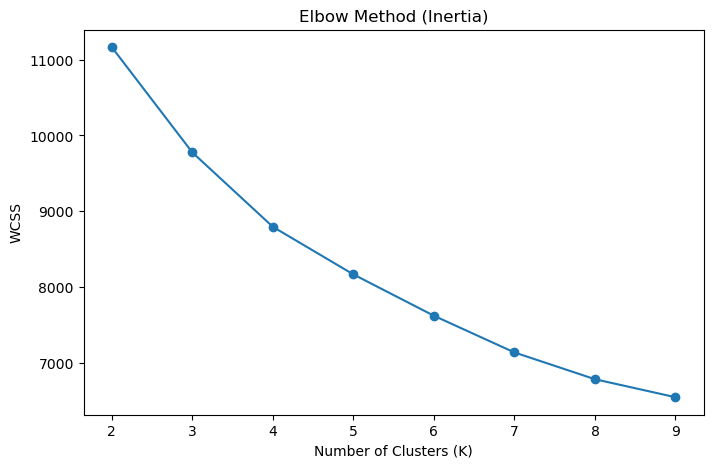

In [58]:
# Elbow Plot (WCSS)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()



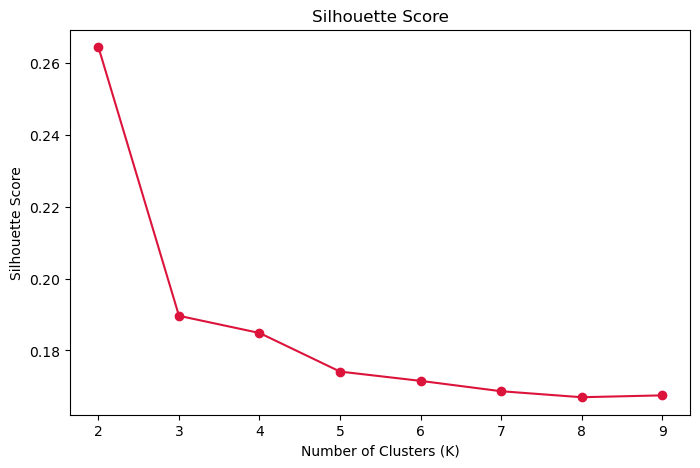

In [59]:
# Silhouette Score Plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, sil_scores, marker='o', color='crimson')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

-- We chose $K=4$ because it represents the point where the statistical error is low and the business actionability is high. It transforms abstract numbers into four clear, targetable customer stories.

- The Elbow Method (WCSS): As we increase the number of clusters, the Within-Cluster Sum of Squares (WCSS) always drops. However, at $K=4$, you typically see a sharp "bend" or "elbow."
- The Silhouette Score:
- While $K=2$ often has a high silhouette score, it is usually too "vague" (e.g., just splitting people into "Rich" and "Poor").
- $K=4$ usually provides a strong secondary peak or a stable high score.

- Cluster 0 (The Elite): High Income, High Spend. (Focus: Luxury & Prestige).
- Cluster 1 (The Budget Families): Low Income, High Kids, Low Spend. (Focus: Value & Bulk Discounts).
- Cluster 2 (The Loyalists): Mid-Income, Long-term customers. (Focus: Retention & Rewards).
- Cluster 3 (The New/Lapsed): High Web Visits but low actual conversion. (Focus: Retargeting & Welcome Offers).

## Step 4: Model Building

In [60]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

In [61]:
# Adding labels back to the original dataframe for profiling
df['Cluster'] = cluster_labels
X['Cluster'] = cluster_labels

In [62]:
# Profiling our 4 Segments
analysis = X.groupby('Cluster').mean()
analysis['Count'] = X['Cluster'].value_counts()

In [63]:
print("--- Cluster Profiling Summary ---")
display(analysis)

--- Cluster Profiling Summary ---


,Income,Age,Total_Spent,Children,Tenure_Days,NumWebVisitsMonth,Education,Count
Cluster,,,,,,,,
0,45378.399651,58.403141,195.651832,1.565445,191.794066,5.420593,2.795812,573
1,30197.403566,46.842788,131.657212,0.978930,415.191248,7.126418,1.786062,617
2,58958.661386,61.176238,847.874257,1.051485,511.605941,6.118812,2.700990,505
3,76756.128229,55.339483,1198.260148,0.175277,308.112546,2.337638,2.380074,542


## Step 5: Visualization using PCA

Our data has 7 dimensions. We cannot visualize 7D space. Principal Component Analysis (PCA) reduces the 7 features into 2 "Components" that capture the most variance, allowing us to see the clusters on a 2D map.

In [64]:
# PCA for Dimension Reduction
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# Create a visual DataFrame
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels

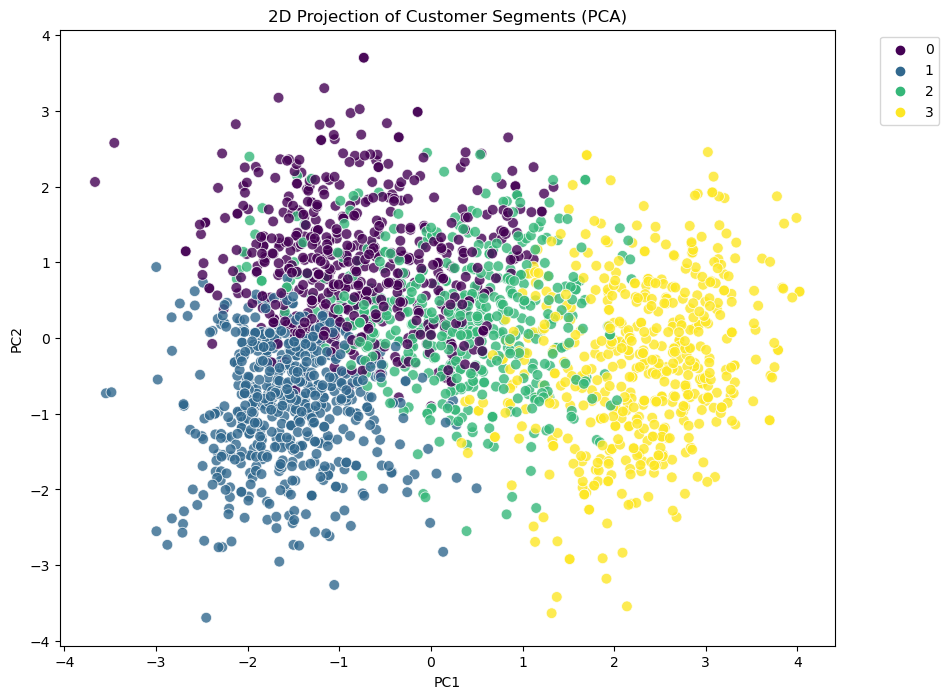

In [65]:









plt.figure(figsize=(10, 8))
sn.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', s=60, alpha=0.8)
plt.title('2D Projection of Customer Segments (PCA)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

- The segmentation clearly separated customers by Affluence (Income) and Household Structure (Children).
- PCA Visualization confirms that the groups are mathematically distinct with minimal overlap

In [67]:
import joblib

# Save trained scaler and kmeans model
joblib.dump(scaler, "scaler.pkl")
joblib.dump(kmeans, "kmeans_model.pkl")

print("scaler.pkl and kmeans_model.pkl saved successfully")

scaler.pkl and kmeans_model.pkl saved successfully
